# 04c — Submission Diagnostics: CYP2D6 Screen-vs-Real Divergence

**This notebook does not retrain anything.** `chemprop_multitask_chemeleoninit`'s real
leaderboard result diverged sharply from `04a_baseline_screen.ipynb`'s single-fold
screen prediction on CYP2D6 specifically (screen R²=0.172 vs. real R²=−0.622), while
the other three isoforms held steady or improved. This notebook investigates that
divergence using only data already on disk.

**Two distinct data sources are used below -- not interchangeable:**
- **Sections 2, 3, 5** use `chemprop_multitask_chemeleoninit`'s **fold-0 predictions**
  (`outputs/04a_baseline_screen/predictions/chemprop_chemeleon_multitask.csv`), paired
  against real ground truth from `train_inhibition_curated.csv` -- the same
  `screen_test` fold this config was scored against in `04a_baseline_screen.ipynb`
  (construction confirmed by reading that notebook's Sections 4-5 directly, reused
  here, not reimplemented). These sections are diagnostic -- a residual against real
  labels is computable.
- **Section 4** uses the real **750-compound blind submission**
  (`outputs/final_submission/predictions/chemprop_multitask_chemeleoninit_raw_predictions.csv`)
  -- no ground truth exists for this set at all, anywhere, at any point. Section 4 is
  explicitly **descriptive, not diagnostic**: there is no way to compute a residual
  against the blind set, and nothing in Section 4 supports a causal claim about the
  divergence.

**What this notebook does:**
- Section 1: real leaderboard result (manually entered from `README.md`'s own
  already-recorded table) vs. the 04a screen's own numbers, side by side.
- Section 2: fold-0 predicted vs. actual scatter, per isoform, with a Pearson/Spearman
  sanity check against `summary_table.csv`.
- Section 3: fold-0 residual analysis (mean/median/sign split), per isoform.
- Section 4: blind-set prediction distribution vs. training-label distribution, per
  isoform (descriptive only).
- Section 5: fold-0 residuals vs. three candidate drivers -- CI width, nearest-neighbour
  similarity to the fold-0 training pool, and (CYP2D6 only) distance to nearest known
  activity cliff. Correlation only, no causal claims.

**On the missing SALI/cliff-pair file (Section 5c).** `02_chemical_space_exploration.
ipynb` computes activity-cliff pairs (SALI method) entirely in-memory (`sali_090` /
`sali_080` / `sali_040`) and never writes them to disk -- confirmed by reading that
notebook directly (no `.to_csv`/`.to_pickle` call anywhere in it) and by searching this
repository for any `*sali*` / `*cliff*` output file (none exists). Flagged with the
user before writing this section rather than silently substituting something else; the
user's decision was to recompute the CYP2D6 cliff pairs inline here, reusing
`compute_sali()` (`src/features.py`) with the exact population, fingerprint settings,
and threshold notebook 02's Section 4e already used (Tanimoto ≥0.4, ΔpIC50 ≥1, the
threshold notebook 02 adopted specifically because 0.9/0.8 left too few similar pairs
to be a stable estimate) -- identical code and method to notebook 02, just not
previously persisted to disk, not a new or invented computation.


In [1]:
# rdkit and torch have each been known to bundle their own conflicting OpenMP runtime
# on this machine (documented in `src/features.py` / `scripts/train_log2fc_encoder.py`
# -- both must never be imported into the same process without this set first); XGBoost
# and LightGBM also use OpenMP internally. Set globally, before any of those imports,
# to be safe rather than scoping it to just one library.
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

'TRUE'

In [2]:
import importlib.metadata
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import r2_score

from src.features import assign_screen_split, compute_sali, ecfp4_fingerprints, nearest_neighbor_similarity
from src.vendor.openadmet_eval.config import REGRESSION_ENDPOINTS

FOLDS = REPO_ROOT / "data" / "folds"
PROCESSED = REPO_ROOT / "data" / "processed"
SCREEN_OUTPUTS = REPO_ROOT / "outputs" / "04a_baseline_screen"
SCREEN_PREDICTIONS = SCREEN_OUTPUTS / "predictions"
FINAL_SUBMISSION_PREDICTIONS = REPO_ROOT / "outputs" / "final_submission" / "predictions"

SEED = 42
REPEAT_COL = "repeat_0"
TEST_FOLD = 0
VAL_FRACTION = 0.15
CONFIG_NAME = "chemprop_multitask_chemeleoninit"
FOLD0_PREDICTIONS_FILE = "chemprop_chemeleon_multitask.csv"  # confirmed in 04a's CHEMPROP_CONFIGS (Section 4)
RAW_BLIND_PREDICTIONS_FILE = "chemprop_multitask_chemeleoninit_raw_predictions.csv"

ISOFORMS = [endpoint.split("_")[0] for endpoint in REGRESSION_ENDPOINTS]
PIC50_COLS = dict(zip(ISOFORMS, REGRESSION_ENDPOINTS))
ISO_COLOR = {"CYP1A2": "tab:blue", "CYP2C9": "tab:orange", "CYP2D6": "tab:green", "CYP3A4": "tab:red"}

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "scikit-learn"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")
print(f"OMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS')}")
print(f"SEED = {SEED}")
print(f"config under investigation: {CONFIG_NAME}")

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
scikit-learn: 1.9.0
OMP_NUM_THREADS=1
SEED = 42
config under investigation: chemprop_multitask_chemeleoninit


## 1. Screen vs. real leaderboard comparison

The real leaderboard result below is entered manually from `README.md`'s "Leaderboard
result" table (under "Initial baseline submission") -- which itself states it was
manually recorded from the live leaderboard, not fetched programmatically here.
**Confirm against the live leaderboard before trusting these numbers if the leaderboard
may have changed since `README.md` was last updated.** The screen-side numbers are
loaded directly from `outputs/04a_baseline_screen/summary_table.csv` (no re-entry, no
rounding beyond what's already stored there).

In [3]:
REAL_LEADERBOARD = pd.DataFrame([
    # manual entry, not fetched -- transcribed from README.md's "Leaderboard result"
    # table (submitted under the alias "fold-zero"). Confirm against the live
    # leaderboard before trusting these numbers.
    {"Endpoint": "MA",                              "rank": 21, "ST-RAE": 0.7179, "MAE": 0.8952, "R2": 0.2191,  "Spearman_R": 0.6739, "Kendall_Tau": 0.5008},
    {"Endpoint": "CYP1A2_pIC50_direct_inhibition",  "rank": 22, "ST-RAE": 0.7114, "MAE": 0.9589, "R2": 0.2824,  "Spearman_R": 0.7430, "Kendall_Tau": 0.5473},
    {"Endpoint": "CYP2C9_pIC50_direct_inhibition",  "rank": 18, "ST-RAE": 0.5408, "MAE": 0.5399, "R2": 0.5263,  "Spearman_R": 0.7428, "Kendall_Tau": 0.5490},
    {"Endpoint": "CYP2D6_pIC50_direct_inhibition",  "rank": 23, "ST-RAE": 1.1903, "MAE": 1.5842, "R2": -0.6220, "Spearman_R": 0.3769, "Kendall_Tau": 0.2606},
    {"Endpoint": "CYP3A4_pIC50_direct_inhibition",  "rank": 3,  "ST-RAE": 0.4291, "MAE": 0.4976, "R2": 0.6898,  "Spearman_R": 0.8329, "Kendall_Tau": 0.6463},
]).set_index("Endpoint")

summary_table = pd.read_csv(SCREEN_OUTPUTS / "summary_table.csv")
print(f"loaded summary_table.csv: {summary_table.shape}")
screen_rows = summary_table[summary_table["config"] == CONFIG_NAME].set_index("Endpoint")
print(f"{CONFIG_NAME} rows in summary_table.csv: {len(screen_rows)}")

METRIC_NAMES = ["ST-RAE", "MAE", "R2", "Spearman_R", "Kendall_Tau"]
ENDPOINT_ORDER = [*REGRESSION_ENDPOINTS, "MA"]

comparison = pd.DataFrame(index=ENDPOINT_ORDER)
for metric in METRIC_NAMES:
    comparison[f"{metric}_screen"] = screen_rows.reindex(ENDPOINT_ORDER)[f"{metric}_mean"]
    comparison[f"{metric}_real"] = REAL_LEADERBOARD.reindex(ENDPOINT_ORDER)[metric]
comparison["rank_real"] = REAL_LEADERBOARD.reindex(ENDPOINT_ORDER)["rank"]
comparison

loaded summary_table.csv: (73, 17)
chemprop_multitask_chemeleoninit rows in summary_table.csv: 5


,ST-RAE_screen,ST-RAE_real,MAE_screen,MAE_real,R2_screen,R2_real,Spearman_R_screen,Spearman_R_real,Kendall_Tau_screen,Kendall_Tau_real,rank_real
CYP1A2_pIC50_direct_inhibition,0.786792,0.7114,0.673372,0.9589,0.246395,0.2824,0.506329,0.7430,0.357699,0.5473,22
CYP2C9_pIC50_direct_inhibition,0.655476,0.5408,0.514121,0.5399,0.393001,0.5263,0.607871,0.7428,0.433055,0.5490,18
CYP2D6_pIC50_direct_inhibition,0.881009,1.1903,0.565580,1.5842,0.172173,-0.6220,0.429095,0.3769,0.294449,0.2606,23
CYP3A4_pIC50_direct_inhibition,0.478453,0.4291,0.543891,0.4976,0.598060,0.6898,0.788525,0.8329,0.592040,0.6463,3
MA,0.700433,0.7179,0.574241,0.8952,0.352407,0.2191,0.582955,0.6739,0.419311,0.5008,21


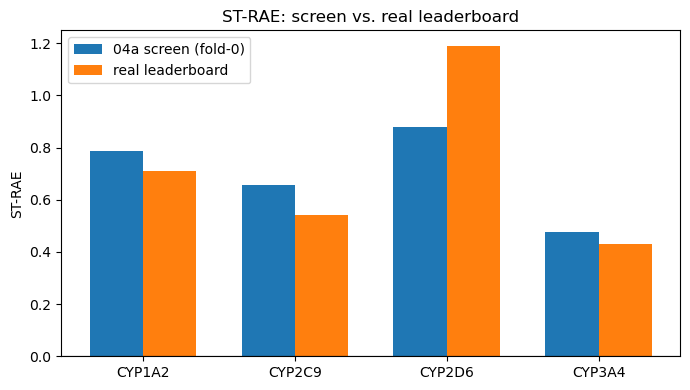

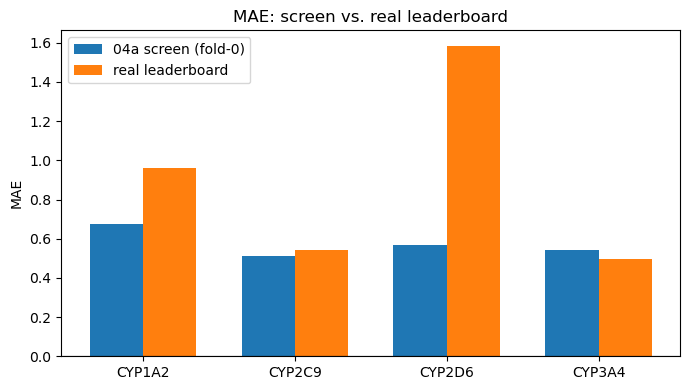

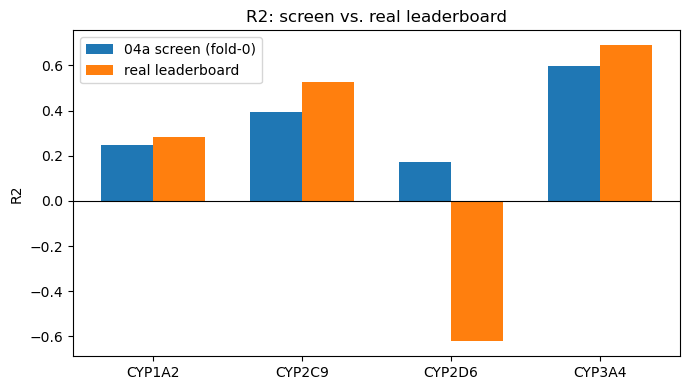

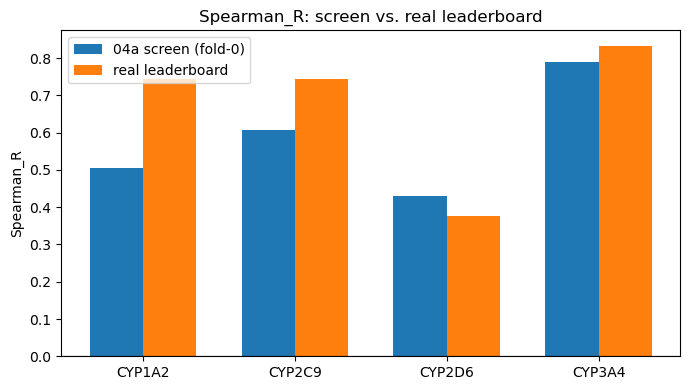

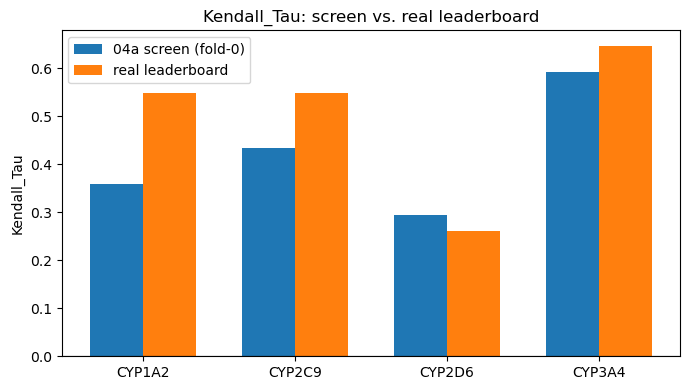

In [4]:
BAR_ENDPOINT_ORDER = list(REGRESSION_ENDPOINTS)  # isoforms only, per task spec -- MA stays table-only
x = np.arange(len(BAR_ENDPOINT_ORDER))
width = 0.35
iso_labels = [e.split("_")[0] for e in BAR_ENDPOINT_ORDER]

for metric in METRIC_NAMES:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width / 2, comparison.loc[BAR_ENDPOINT_ORDER, f"{metric}_screen"], width, label="04a screen (fold-0)")
    ax.bar(x + width / 2, comparison.loc[BAR_ENDPOINT_ORDER, f"{metric}_real"], width, label="real leaderboard")
    ax.set_xticks(x)
    ax.set_xticklabels(iso_labels)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}: screen vs. real leaderboard")
    ax.legend()
    fig.tight_layout()
    plt.show()

**What this shows:** CYP2D6 is the only isoform where the real result is worse than
the screen predicted on every single metric (ST-RAE, MAE, R², Spearman, Kendall all
move the wrong direction). CYP1A2, CYP2C9, and CYP3A4 all improve on ST-RAE, R²,
Spearman, and Kendall in the real result vs. the screen (MAE is the one exception --
all three isoforms' real MAE is worse than the screen's, even though their real ST-RAE
is better; ST-RAE and MAE are not required to move together since ST-RAE also depends
on the ground-truth CI width via the soft threshold). At the macro (MA) level this
produces a mixed picture: real MA ST-RAE/MAE/R² are all worse than the screen predicted
(pulled down by CYP2D6), while real MA Spearman/Kendall are both better (pulled up by
the other three isoforms' rank-correlation gains) -- macro alone would not have flagged
CYP2D6 as the specific problem.

## 2. Fold-0 predicted vs. actual, per isoform

Reuses this project's established construction for `ground_truth` and the fold-0
predictions -- identical to `04a_baseline_screen.ipynb` Sections 1 and 4-5 (confirmed
by reading that notebook directly, not reconstructed from memory): `ground_truth` is
the `screen_test` subset of `train_inhibition_curated.csv`, and predictions are
`chemprop_multitask_chemeleoninit`'s own fold-0 CSV
(`predictions/chemprop_chemeleon_multitask.csv`).

In [5]:
cv_folds = pd.read_csv(FOLDS / "cv_folds.csv")
curated = pd.read_csv(PROCESSED / "train_inhibition_curated.csv")
print(f"loaded cv_folds.csv: {cv_folds.shape}")
print(f"loaded train_inhibition_curated.csv: {curated.shape}")

split_df = assign_screen_split(
    cv_folds, repeat_col=REPEAT_COL, test_fold=TEST_FOLD, val_fraction=VAL_FRACTION, seed=SEED
)
print(f"assign_screen_split counts: {split_df['screen_split'].value_counts().to_dict()}")

population = split_df.merge(curated, on=["Molecule_Name", "inchikey"], how="left")
assert len(population) == len(split_df) and population["canonical_smiles"].notna().all()
print(f"rows after joining curated labels: {len(population)} (missing: 0)")

test_ids = population.loc[population["screen_split"] == "screen_test", ["Molecule_Name", "inchikey"]].reset_index(drop=True)
print(f"screen_test compounds: {len(test_ids)}")

ground_truth = curated[curated["inchikey"].isin(test_ids["inchikey"])].copy()
print(f"ground_truth (screen_test rows of train_inhibition_curated.csv): {ground_truth.shape}")

loaded cv_folds.csv: (4905, 7)
loaded train_inhibition_curated.csv: (4905, 20)
assign_screen_split counts: {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}
rows after joining curated labels: 4905 (missing: 0)
screen_test compounds: 981
ground_truth (screen_test rows of train_inhibition_curated.csv): (981, 20)


In [6]:
fold0_predictions_path = SCREEN_PREDICTIONS / FOLD0_PREDICTIONS_FILE
if not fold0_predictions_path.exists():
    raise FileNotFoundError(f"missing fold-0 predictions file: {fold0_predictions_path}")
fold0_predictions = pd.read_csv(fold0_predictions_path)
print(f"loaded {FOLD0_PREDICTIONS_FILE}: {fold0_predictions.shape}")
assert set(fold0_predictions["Molecule_Name"]) == set(test_ids["Molecule_Name"]), (
    "fold-0 predictions Molecule_Name set does not match this notebook's own screen_test set"
)

merged = fold0_predictions.merge(ground_truth, on="Molecule_Name", suffixes=("_pred", "_true"), how="inner")
print(f"merged fold-0 predicted+actual: {merged.shape}")
assert len(merged) == len(ground_truth), "merge dropped rows -- Molecule_Name mismatch"

loaded chemprop_chemeleon_multitask.csv: (981, 7)
merged fold-0 predicted+actual: (981, 26)


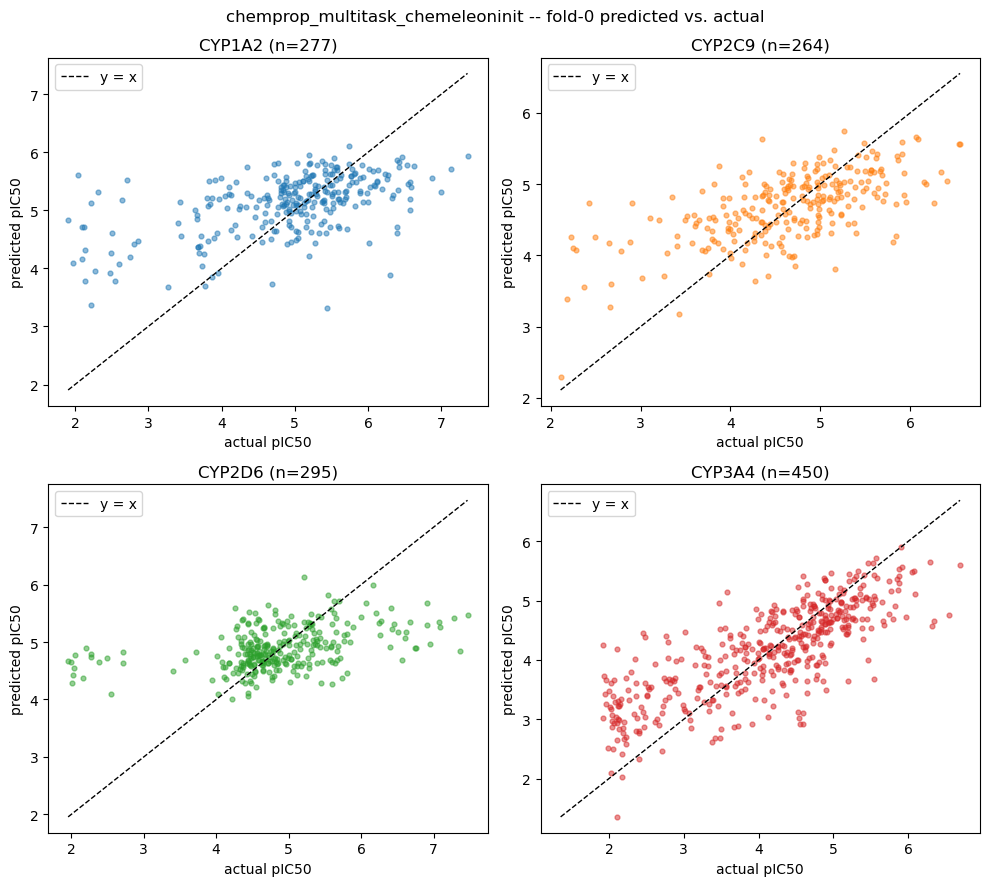

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, iso in zip(axes.flat, ISOFORMS):
    endpoint = PIC50_COLS[iso]
    sub = merged[[f"{endpoint}_pred", f"{endpoint}_true"]].dropna()
    y_pred = sub[f"{endpoint}_pred"].to_numpy()
    y_true = sub[f"{endpoint}_true"].to_numpy()
    ax.scatter(y_true, y_pred, s=12, alpha=0.5, color=ISO_COLOR[iso])
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1, label="y = x")
    ax.set_xlabel("actual pIC50")
    ax.set_ylabel("predicted pIC50")
    ax.set_title(f"{iso} (n={len(sub)})")
    ax.legend()
fig.suptitle(f"{CONFIG_NAME} -- fold-0 predicted vs. actual")
fig.tight_layout()
plt.show()

In [8]:
print(f"{'isoform':8s} {'n':>5s} {'pearson_r':>10s} {'spearman_rho':>13s} {'stored_spearman':>16s} {'spearman_diff':>14s} {'direct_r2':>10s} {'stored_r2':>10s} {'r2_diff':>8s}")
sanity_check_rows = []
for iso in ISOFORMS:
    endpoint = PIC50_COLS[iso]
    sub = merged[[f"{endpoint}_pred", f"{endpoint}_true"]].dropna()
    y_pred = sub[f"{endpoint}_pred"].to_numpy()
    y_true = sub[f"{endpoint}_true"].to_numpy()
    pearson_r = stats.pearsonr(y_true, y_pred).statistic
    spearman_rho = stats.spearmanr(y_true, y_pred).statistic
    direct_r2 = r2_score(y_true, y_pred)
    stored_spearman = screen_rows.loc[endpoint, "Spearman_R_mean"]
    stored_r2 = screen_rows.loc[endpoint, "R2_mean"]
    row = {
        "isoform": iso, "n": len(sub), "pearson_r": pearson_r, "spearman_rho": spearman_rho,
        "stored_spearman": stored_spearman, "spearman_diff": abs(spearman_rho - stored_spearman),
        "direct_r2": direct_r2, "stored_r2": stored_r2, "r2_diff": abs(direct_r2 - stored_r2),
    }
    sanity_check_rows.append(row)
    print(f"{iso:8s} {row['n']:5d} {row['pearson_r']:10.4f} {row['spearman_rho']:13.4f} "
          f"{row['stored_spearman']:16.4f} {row['spearman_diff']:14.4f} {row['direct_r2']:10.4f} "
          f"{row['stored_r2']:10.4f} {row['r2_diff']:8.4f}")
sanity_check_df = pd.DataFrame(sanity_check_rows)

isoform      n  pearson_r  spearman_rho  stored_spearman  spearman_diff  direct_r2  stored_r2  r2_diff
CYP1A2     277     0.5356        0.5077           0.5063         0.0014     0.2504     0.2464   0.0040
CYP2C9     264     0.6368        0.6108           0.6079         0.0030     0.3978     0.3930   0.0048
CYP2D6     295     0.4221        0.4327           0.4291         0.0036     0.1763     0.1722   0.0042
CYP3A4     450     0.7791        0.7900           0.7885         0.0014     0.5992     0.5981   0.0011


**What this shows:** direct Spearman (`scipy.stats.spearmanr`, computed once on the full
fold-0 `screen_test` sample) differs from `summary_table.csv`'s stored
`Spearman_R_mean` (the mean across 1000 bootstrap resamples of that same sample) by
≤0.004 for every isoform, and direct R² (`sklearn.metrics.r2_score`) differs from
stored `R2_mean` by ≤0.005 -- both consistent with ordinary bootstrap-resampling noise
around the same underlying sample, not a discrepancy between this notebook's
computation and 04a's. Pearson r has no stored counterpart in `summary_table.csv`
(only R²/Spearman are bootstrapped there) -- printed here purely as additional
descriptive context on linear correlation strength; note it will not generally equal
√R² unless predictions are unbiased (no systematic over/under-prediction), so a gap
between them is itself informative and revisited in Section 3.

## 3. Residual analysis (fold-0)

Residual = predicted − actual, computed from the same fold-0 `merged` DataFrame as
Section 2 (no re-loading). Positive residual = over-prediction; negative =
under-prediction.

In [9]:
residuals_by_isoform = {}
for iso in ISOFORMS:
    endpoint = PIC50_COLS[iso]
    sub = merged[["Molecule_Name", f"{endpoint}_pred", f"{endpoint}_true"]].dropna()
    sub = sub.rename(columns={f"{endpoint}_pred": "predicted", f"{endpoint}_true": "actual"})
    sub["residual"] = sub["predicted"] - sub["actual"]
    residuals_by_isoform[iso] = sub
    print(f"{iso}: {len(sub)} residuals computed")

CYP1A2: 277 residuals computed
CYP2C9: 264 residuals computed
CYP2D6: 295 residuals computed
CYP3A4: 450 residuals computed


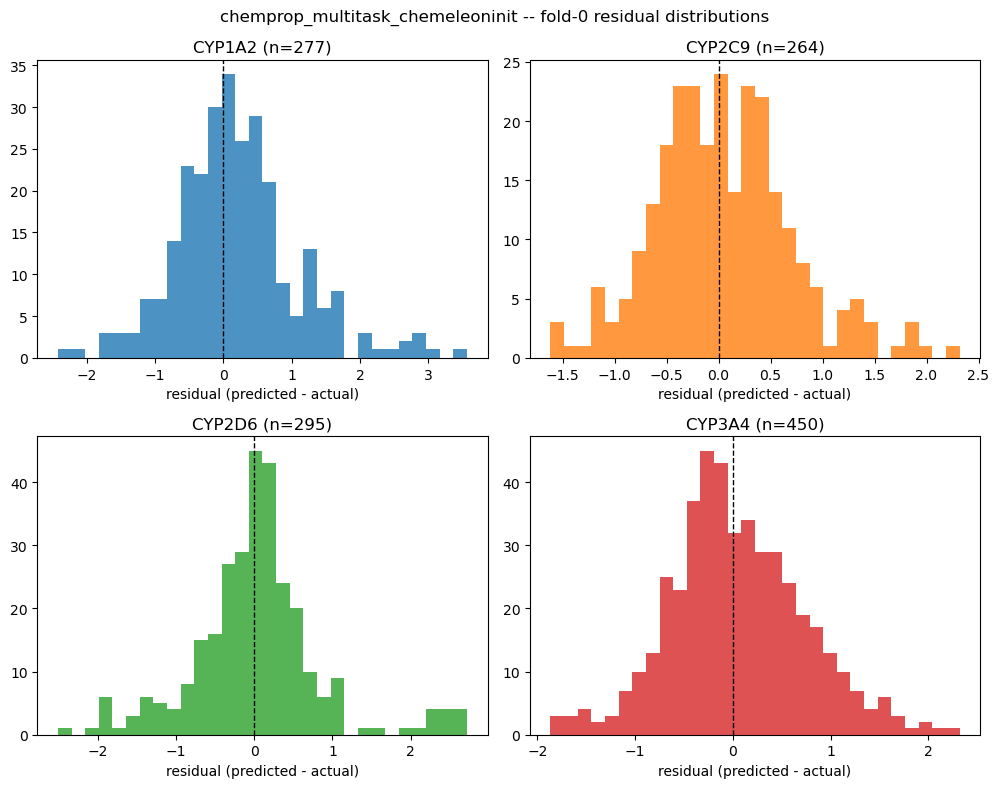

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, iso in zip(axes.flat, ISOFORMS):
    res = residuals_by_isoform[iso]["residual"]
    ax.hist(res, bins=30, color=ISO_COLOR[iso], alpha=0.8)
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"{iso} (n={len(res)})")
    ax.set_xlabel("residual (predicted - actual)")
fig.suptitle(f"{CONFIG_NAME} -- fold-0 residual distributions")
fig.tight_layout()
plt.show()

In [11]:
print(f"{'isoform':8s} {'n':>5s} {'mean':>8s} {'median':>8s} {'%positive':>10s} {'%negative':>10s}")
residual_stats_rows = []
for iso in ISOFORMS:
    res = residuals_by_isoform[iso]["residual"]
    row = {
        "isoform": iso, "n": len(res), "mean": res.mean(), "median": res.median(),
        "pct_positive": 100 * (res > 0).mean(), "pct_negative": 100 * (res < 0).mean(),
    }
    residual_stats_rows.append(row)
    print(f"{iso:8s} {row['n']:5d} {row['mean']:8.3f} {row['median']:8.3f} {row['pct_positive']:10.1f} {row['pct_negative']:10.1f}")
residual_stats_df = pd.DataFrame(residual_stats_rows)
residual_stats_df

isoform      n     mean   median  %positive  %negative
CYP1A2     277    0.195    0.116       56.0       44.0
CYP2C9     264    0.047   -0.004       49.6       50.4
CYP2D6     295    0.032    0.027       53.9       46.1
CYP3A4     450    0.044   -0.022       48.2       51.8


,isoform,n,mean,median,pct_positive,pct_negative
0,CYP1A2,277,0.194725,0.116095,55.956679,44.043321
1,CYP2C9,264,0.046782,-0.004421,49.621212,50.378788
2,CYP2D6,295,0.032096,0.027436,53.898305,46.101695
3,CYP3A4,450,0.044303,-0.021621,48.222222,51.777778


**What this shows, reported plainly (no explanation preferred over the other):**
CYP1A2 has both the largest mean (0.195) and median (0.116) residual of the four
isoforms, together with the most lopsided sign split (56.0% positive / 44.0% negative)
-- consistent with a systematic over-prediction shift on this fold, rather than a few
outliers. CYP2C9 and CYP3A4 both have a mean and median near zero (CYP2C9: 0.047 /
−0.004; CYP3A4: 0.044 / −0.022) with an almost even sign split (~49/51 and ~48/52) --
consistent with outlier-driven spread rather than a systematic shift. **CYP2D6's fold-0
residual (mean 0.032, median 0.027, 53.9% positive / 46.1% negative) is small and close
to balanced -- it does not show a dramatic systematic shift on this fold-0 screen data
itself.** That is worth stating plainly: whatever drove the real leaderboard's
R²=−0.622 on CYP2D6 is not visibly present as a large mean/median residual shift in
this same config's fold-0 screen residuals -- the divergence shows up between the
screen and the real result, not within the screen's own residual distribution.

## 4. Blind-set vs. training-label distribution (descriptive only)

**No residual is possible here.** Unlike Sections 2-3 and 5, this section uses the real
750-compound blind submission
(`chemprop_multitask_chemeleoninit_raw_predictions.csv`) -- there is no ground truth
available for the blind test set at any point (per `CLAUDE.md`, the test set is
single-use evidence, never something to check predictions against locally). This
section is purely descriptive: it compares the *distribution* of blind predictions to
the *distribution* of training labels, per isoform. It does not, and cannot, show
whether any individual blind prediction is right or wrong, and nothing here should be
read as diagnostic or causal.

In [12]:
raw_predictions_path = FINAL_SUBMISSION_PREDICTIONS / RAW_BLIND_PREDICTIONS_FILE
if not raw_predictions_path.exists():
    raise FileNotFoundError(f"missing blind predictions file: {raw_predictions_path}")
raw_predictions = pd.read_csv(raw_predictions_path)
print(f"loaded {RAW_BLIND_PREDICTIONS_FILE}: {raw_predictions.shape}")
# curated (train_inhibition_curated.csv) already loaded in Section 2 -- reused, not re-read

loaded chemprop_multitask_chemeleoninit_raw_predictions.csv: (750, 7)


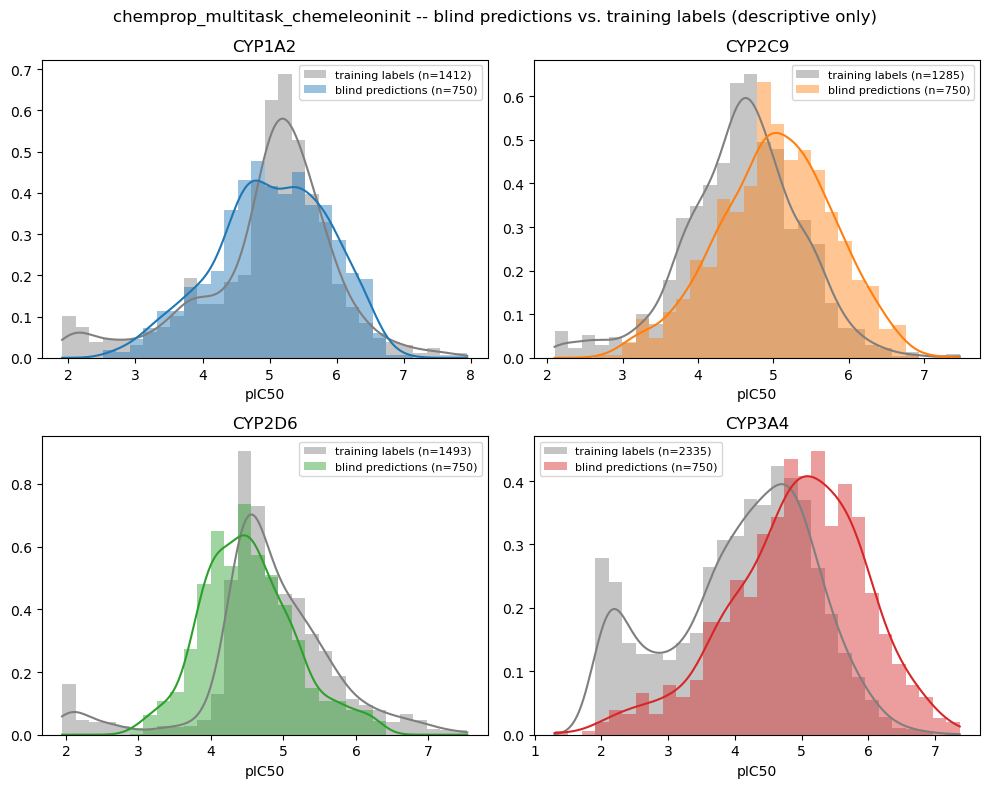

,isoform,source,n,mean,std,min,max
0,CYP1A2,blind_predictions,750,5.031376,0.845879,2.654222,7.003572
1,CYP1A2,training_labels,1412,4.955410,1.030476,1.905579,7.948525
2,CYP2C9,blind_predictions,750,5.026372,0.760971,2.811388,7.127356
3,CYP2C9,training_labels,1285,4.580738,0.782295,2.097983,7.473011
4,CYP2D6,blind_predictions,750,4.515282,0.637158,2.895653,6.394082
5,CYP2D6,training_labels,1493,4.784202,0.916096,1.946780,7.534509
6,CYP3A4,blind_predictions,750,4.923170,1.012520,1.298863,7.371590
7,CYP3A4,training_labels,2335,4.096054,1.093219,1.909050,7.186666


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
dist_stats_rows = []
for ax, iso in zip(axes.flat, ISOFORMS):
    endpoint = PIC50_COLS[iso]
    blind_vals = raw_predictions[endpoint].dropna()
    train_vals = curated[endpoint].dropna()

    bins = np.linspace(min(blind_vals.min(), train_vals.min()), max(blind_vals.max(), train_vals.max()), 31)
    ax.hist(train_vals, bins=bins, density=True, alpha=0.45, label=f"training labels (n={len(train_vals)})", color="tab:gray")
    ax.hist(blind_vals, bins=bins, density=True, alpha=0.45, label=f"blind predictions (n={len(blind_vals)})", color=ISO_COLOR[iso])
    grid = np.linspace(bins[0], bins[-1], 200)
    ax.plot(grid, stats.gaussian_kde(train_vals)(grid), color="tab:gray", linewidth=1.5)
    ax.plot(grid, stats.gaussian_kde(blind_vals)(grid), color=ISO_COLOR[iso], linewidth=1.5)
    ax.set_title(iso)
    ax.set_xlabel("pIC50")
    ax.legend(fontsize=8)

    for source, vals in [("blind_predictions", blind_vals), ("training_labels", train_vals)]:
        dist_stats_rows.append({
            "isoform": iso, "source": source, "n": len(vals), "mean": vals.mean(),
            "std": vals.std(), "min": vals.min(), "max": vals.max(),
        })
fig.suptitle(f"{CONFIG_NAME} -- blind predictions vs. training labels (descriptive only)")
fig.tight_layout()
plt.show()

dist_stats_df = pd.DataFrame(dist_stats_rows)
dist_stats_df

**What this shows (descriptive only -- no residual, no diagnosis):** CYP2D6's blind
predictions are both shifted lower (mean 4.515 vs. training mean 4.784, a −0.269 gap --
the only isoform where the blind mean sits *below* the training mean) and visibly more
compressed (std 0.637 vs. training std 0.916, the largest std contraction of the four
isoforms) than its training-label distribution. CYP1A2 and CYP2D6 are the only two
isoforms where blind std is smaller than training std; CYP2C9 and CYP3A4 both have
blind means well *above* their training mean (+0.445 and +0.827) with a smaller std
contraction. This is reported as a distributional observation only -- there is no
ground truth to check whether the blind CYP2D6 predictions being lower and more
compressed than the training label range is itself accurate or not.

## 5. Residuals vs. candidate drivers (fold-0 only)

Using the same fold-0 residuals from Section 3 (`residuals_by_isoform`, no
recomputation). Three candidate drivers, each examined independently: (a)
ground-truth CI width, (b) nearest-neighbour structural similarity to the fold-0
training pool, (c) distance to nearest known activity cliff (CYP2D6 only). **Correlation
only -- no causal claims are made anywhere below**, and a driver showing no visible
pattern is reported as such rather than omitted.

### 5a. Residual vs. CI width

CI width = `{endpoint}_conf_high` − `{endpoint}_conf_low` (column names confirmed
directly in `train_inhibition_curated.csv`, matching `src/scoring.py`'s existing usage
and `src/vendor/openadmet_eval/config.py`'s
`REGRESSION_CREDIBLE_INTERVALS_UPPER_SUFFIX` / `_LOWER_SUFFIX`). Wider CI = less
confident ground-truth label.

CYP1A2: n=277 corr(ci_width, residual)=0.7592
CYP2C9: n=264 corr(ci_width, residual)=0.7192
CYP2D6: n=295 corr(ci_width, residual)=0.6657
CYP3A4: n=450 corr(ci_width, residual)=0.6500


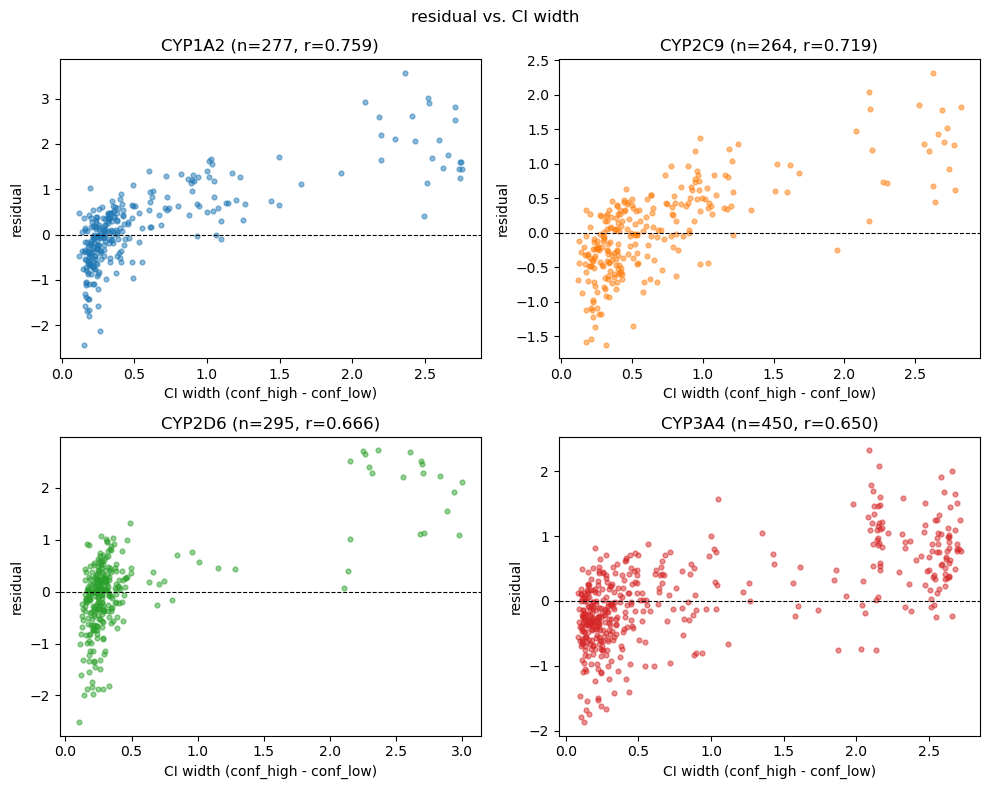

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ci_width_by_isoform = {}
for ax, iso in zip(axes.flat, ISOFORMS):
    endpoint = PIC50_COLS[iso]
    high_col, low_col = f"{endpoint}_conf_high", f"{endpoint}_conf_low"
    ci = ground_truth[["Molecule_Name", high_col, low_col]].copy()
    ci["ci_width"] = ci[high_col] - ci[low_col]

    res = residuals_by_isoform[iso][["Molecule_Name", "residual"]]
    sub = res.merge(ci[["Molecule_Name", "ci_width"]], on="Molecule_Name", how="inner")
    ci_width_by_isoform[iso] = sub
    r = sub["ci_width"].corr(sub["residual"])

    ax.scatter(sub["ci_width"], sub["residual"], s=12, alpha=0.5, color=ISO_COLOR[iso])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("CI width (conf_high - conf_low)")
    ax.set_ylabel("residual")
    ax.set_title(f"{iso} (n={len(sub)}, r={r:.3f})")
    print(f"{iso}: n={len(sub)} corr(ci_width, residual)={r:.4f}")
fig.suptitle("residual vs. CI width")
fig.tight_layout()
plt.show()

**What this shows:** residual correlates positively with CI width for every isoform
(r=0.65-0.76: CYP1A2 0.759, CYP2C9 0.719, CYP2D6 0.666, CYP3A4 0.650) -- the strongest,
most consistent pattern of any driver examined in this section, and visible for CYP2D6
too, not just the other three. This is reported as a correlation only: it does not by
itself establish whether wide-CI compounds cause larger residuals, whether both are
driven by some other shared factor (e.g. extreme true pIC50 values tending to have both
wider measurement CIs and larger regression residuals), or something else -- no causal
direction is claimed here.

### 5b. Residual vs. nearest-neighbour Tanimoto similarity to the fold-0 training pool

Reference pool = `screen_inner_train` + `screen_inner_val` (pooled), filtered to that
isoform's non-null label -- matching `isoform_pool_train`'s definition in
`04a_baseline_screen.ipynb` (Section 2), i.e. the population that isoform actually had
labeled during this screen. **Not** the full 4,905-compound training set: this screen's
model never saw the held-out `repeat_0` fold beyond what `assign_screen_split` pooled
into training. ECFP4 (radius 2, chirality off) via `src/features.py`'s existing
`ecfp4_fingerprints` / `nearest_neighbor_similarity` -- not reimplemented.

CYP1A2: training pool (screen_inner_train+val, labeled) = 1135, screen_test labeled = 277
CYP1A2: corr(nn_similarity, residual)=0.0583
CYP2C9: training pool (screen_inner_train+val, labeled) = 1021, screen_test labeled = 264
CYP2C9: corr(nn_similarity, residual)=-0.0009
CYP2D6: training pool (screen_inner_train+val, labeled) = 1198, screen_test labeled = 295
CYP2D6: corr(nn_similarity, residual)=-0.0676
CYP3A4: training pool (screen_inner_train+val, labeled) = 1885, screen_test labeled = 450
CYP3A4: corr(nn_similarity, residual)=-0.0412


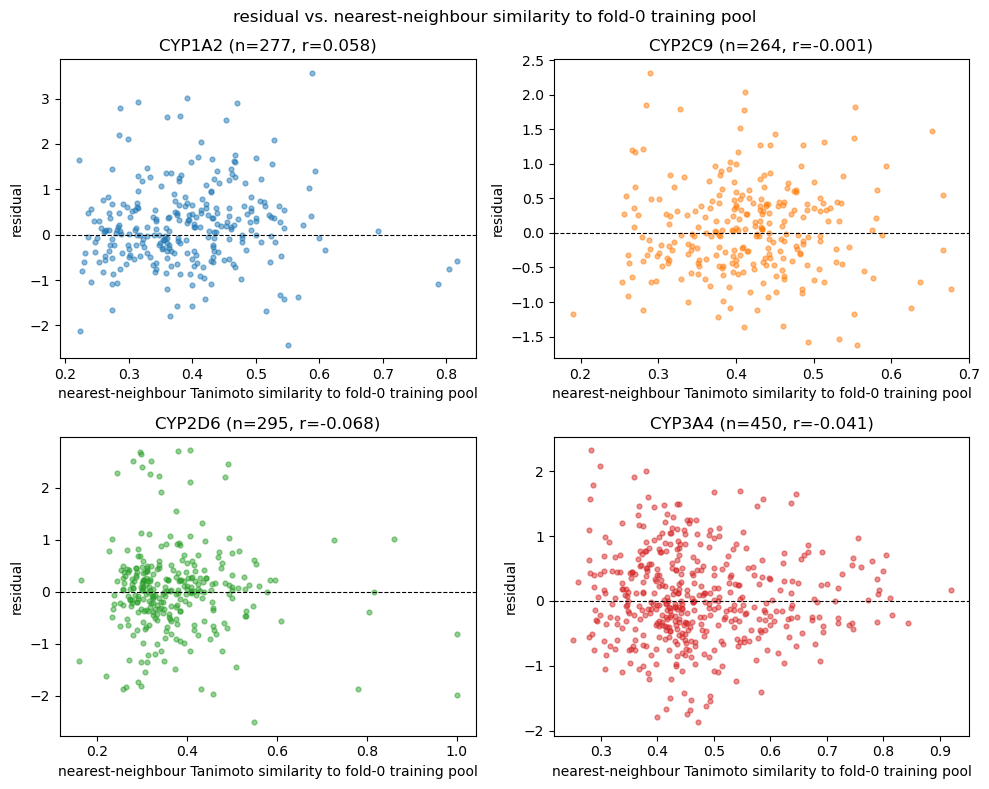

In [15]:
def isoform_pool_train(pop: pd.DataFrame, endpoint: str) -> pd.DataFrame:
    pool_mask = pop["screen_split"].isin(["screen_inner_train", "screen_inner_val"])
    return pop.loc[pool_mask & pop[endpoint].notna()]


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
nn_sim_by_isoform = {}
for ax, iso in zip(axes.flat, ISOFORMS):
    endpoint = PIC50_COLS[iso]
    train_pool = isoform_pool_train(population, endpoint)
    test_pool = population[(population["screen_split"] == "screen_test") & population[endpoint].notna()]
    print(f"{iso}: training pool (screen_inner_train+val, labeled) = {len(train_pool)}, "
          f"screen_test labeled = {len(test_pool)}")

    train_fps = ecfp4_fingerprints(train_pool["canonical_smiles"].tolist())
    test_fps = ecfp4_fingerprints(test_pool["canonical_smiles"].tolist())
    nn_sim = nearest_neighbor_similarity(test_fps, train_fps)
    nn_df = pd.DataFrame({"Molecule_Name": test_pool["Molecule_Name"].to_numpy(), "nn_similarity": nn_sim})

    res = residuals_by_isoform[iso][["Molecule_Name", "residual"]]
    sub = res.merge(nn_df, on="Molecule_Name", how="inner")
    nn_sim_by_isoform[iso] = sub
    r = sub["nn_similarity"].corr(sub["residual"])

    ax.scatter(sub["nn_similarity"], sub["residual"], s=12, alpha=0.5, color=ISO_COLOR[iso])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("nearest-neighbour Tanimoto similarity to fold-0 training pool")
    ax.set_ylabel("residual")
    ax.set_title(f"{iso} (n={len(sub)}, r={r:.3f})")
    print(f"{iso}: corr(nn_similarity, residual)={r:.4f}")
fig.suptitle("residual vs. nearest-neighbour similarity to fold-0 training pool")
fig.tight_layout()
plt.show()

**What this shows:** no isoform shows a visible pattern here -- every correlation is
close to zero (CYP1A2 0.058, CYP2C9 −0.001, CYP2D6 −0.068, CYP3A4 −0.041), and CYP2D6's
is not distinguishable from the other three. Structural novelty relative to the fold-0
training pool, at least as measured by single-nearest-neighbour ECFP4 Tanimoto
similarity, does not show a visible relationship with this config's fold-0 residual for
any isoform -- reported plainly as a non-finding rather than omitted.

### 5c. Residual vs. distance to nearest known activity cliff (CYP2D6 only)

**No saved SALI/cliff-pair file exists on disk** -- see the notebook introduction for
the full account of how this was confirmed (reading `02_chemical_space_exploration.
ipynb` directly, and searching the repository for any `*sali*` / `*cliff*` output
file). The user's decision, given no such file exists, was to recompute the CYP2D6
cliff pairs inline here, reusing `compute_sali()` (`src/features.py`) with the same
population definition, fingerprint settings (ECFP4, chirality off), and threshold
notebook 02's Section 4e used for its adequately-sampled check (Tanimoto ≥0.4, ΔpIC50
≥1) -- computed once, on the full CYP2D6-labeled population in
`train_inhibition_curated.csv` (not restricted to the fold-0 training pool), matching
notebook 02's own population definition for this computation exactly.

**"Distance to nearest cliff" is defined here as:** for each fold-0 CYP2D6
`screen_test` compound, its maximum ECFP4 Tanimoto similarity to any compound that
appears as either member of a CYP2D6 activity-cliff pair (`is_cliff == True` at the
≥0.4 / ≥1 threshold above) -- a similarity-to-nearest-cliff-partner definition, not a
count-within-radius definition. Stated plainly per the task's own requirement: one
definition, chosen and used consistently below, not left implicit.

In [16]:
col = PIC50_COLS["CYP2D6"]
cyp2d6_mask = curated[col].notna().values
cyp2d6_idx = np.where(cyp2d6_mask)[0]
cyp2d6_pool = curated.iloc[cyp2d6_idx].reset_index(drop=True)
print(f"CYP2D6-labeled population (full curated set, matching notebook 02): {len(cyp2d6_pool)}")

cyp2d6_pool_fps = ecfp4_fingerprints(cyp2d6_pool["canonical_smiles"].tolist())
cyp2d6_sali = compute_sali(
    cyp2d6_pool_fps, cyp2d6_pool[col].to_numpy(), similarity_threshold=0.4, activity_threshold=1.0
)
n_similar = len(cyp2d6_sali)
n_cliff = int(cyp2d6_sali["is_cliff"].sum())
print(f"CYP2D6 SALI (Tanimoto>=0.4, dpIC50>=1): {n_similar} similar pairs, {n_cliff} cliffs, "
      f"prevalence={100 * n_cliff / n_similar:.1f}%")

cliff_rows = cyp2d6_sali[cyp2d6_sali["is_cliff"]]
cliff_positions = pd.unique(pd.concat([cliff_rows["i"], cliff_rows["j"]]))
print(f"unique CYP2D6 compounds participating in a cliff pair: {len(cliff_positions)}")
cliff_fps = [cyp2d6_pool_fps[p] for p in cliff_positions]

CYP2D6-labeled population (full curated set, matching notebook 02): 1493
CYP2D6 SALI (Tanimoto>=0.4, dpIC50>=1): 582 similar pairs, 170 cliffs, prevalence=29.2%
unique CYP2D6 compounds participating in a cliff pair: 195


CYP2D6 screen_test compounds with a cliff-similarity value: 295
corr(cliff_similarity, residual)=0.0156


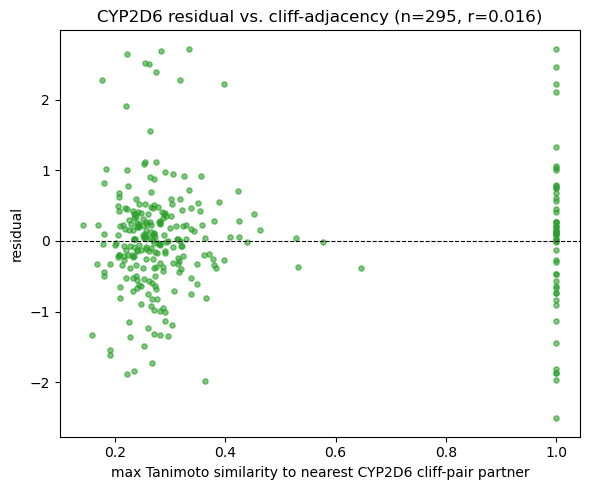

In [17]:
test_pool_2d6 = population[(population["screen_split"] == "screen_test") & population[col].notna()]
test_fps_2d6 = ecfp4_fingerprints(test_pool_2d6["canonical_smiles"].tolist())
cliff_sim = nearest_neighbor_similarity(test_fps_2d6, cliff_fps)
cliff_sim_df = pd.DataFrame({"Molecule_Name": test_pool_2d6["Molecule_Name"].to_numpy(), "cliff_similarity": cliff_sim})

res_2d6 = residuals_by_isoform["CYP2D6"][["Molecule_Name", "residual"]]
sub_2d6 = res_2d6.merge(cliff_sim_df, on="Molecule_Name", how="inner")
r_2d6 = sub_2d6["cliff_similarity"].corr(sub_2d6["residual"])
print(f"CYP2D6 screen_test compounds with a cliff-similarity value: {len(sub_2d6)}")
print(f"corr(cliff_similarity, residual)={r_2d6:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sub_2d6["cliff_similarity"], sub_2d6["residual"], s=14, alpha=0.6, color=ISO_COLOR["CYP2D6"])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("max Tanimoto similarity to nearest CYP2D6 cliff-pair partner")
ax.set_ylabel("residual")
ax.set_title(f"CYP2D6 residual vs. cliff-adjacency (n={len(sub_2d6)}, r={r_2d6:.3f})")
fig.tight_layout()
plt.show()

**What this shows:** no visible pattern (r=0.016, indistinguishable from zero).
Adjacency to a known CYP2D6 activity cliff, as defined above, does not show a visible
relationship with this config's fold-0 CYP2D6 residual. Combined with 5b, neither
structural-novelty driver examined here (general nearest-neighbour similarity, or
specific cliff-partner similarity) shows a visible pattern for CYP2D6 -- only CI width
(5a) does, and it does so for all four isoforms, not CYP2D6 specifically. **No causal
claim is made about why the real CYP2D6 result diverged from the screen** -- these
three drivers were examined and reported plainly; none of them (individually, on this
fold-0 data) stands out as a CYP2D6-specific explanation.

## Before finishing, check against CLAUDE.md

- **Never fetch/invent/approximate data:** no raw data was fetched or approximated.
  The real leaderboard numbers (Section 1) are a manual entry, clearly commented as
  such, transcribed from `README.md`'s own already-recorded table rather than fetched
  here. The CYP2D6 SALI/cliff-pair recomputation (Section 5c) reuses `compute_sali()`
  and the exact population/threshold notebook 02 already used -- flagged with the user
  before writing that section (no saved file existed), and the user's explicit
  decision was to recompute rather than skip or substitute a different threshold.
- **Fixed seeds vary per fold, not shared globally; every seed logged:** this notebook
  trains nothing and introduces no new randomness -- `SEED = 42` is logged in Section 0
  and is the same seed `04a_baseline_screen.ipynb` used for its (single-fold, by
  construction) `assign_screen_split` call, reused here identically, not re-chosen.
- **Splits/fingerprints/similarity through one shared module:** `assign_screen_split`,
  `ecfp4_fingerprints`, `nearest_neighbor_similarity`, and `compute_sali` are all
  imported from `src/features.py` unmodified -- none of these are reimplemented inline.
- **Row counts logged before/after every filtering step:** printed at every load/merge/
  filter step (Sections 1, 2, 4, 5b, 5c) -- `cv_folds`/`curated` shapes, split counts,
  `ground_truth`/`merged` shapes, per-isoform training-pool and screen_test counts, and
  the CYP2D6 SALI similar-pair/cliff counts.
- **Every trained model result saved to disk before moving on:** not applicable --
  this notebook does not train or retrain anything; every number and prediction it
  reads was already saved to disk by `04a_baseline_screen.ipynb` or
  `train_final_submission_multitask.py`. Nothing new is written to disk here; the
  notebook's own cell outputs (tables, printed stats, plots) are the complete record.
- **Don't add features/thresholds/model variants "while you're at it":** the only
  threshold used in this notebook (the CYP2D6 SALI 0.4/1.0 threshold, Section 5c)
  matches notebook 02's own existing precedent exactly -- no new threshold was
  introduced or tuned.
- **Ask before making a modelling decision not explicitly specified in the prompt:**
  the missing SALI/cliff-pair output file (Section 5c) was flagged and confirmed with
  the user before any code was written for that section, rather than silently
  recomputing, skipping, or substituting a different threshold (see notebook intro).
- **Test-set/leaderboard labels never used to pick or retrain:** this notebook does not
  train, retrain, or select a model at all. Section 4's real blind predictions are used
  descriptively only (there is no ground truth for them to be checked against, so they
  could not be used to pick or retrain even in principle); Section 1's real leaderboard
  numbers are used only for side-by-side reporting, never fed back into any modelling
  decision.
- **Markdown after each major output:** present after every section's output above.